`Business Problem`
An online retail company is struggling to improve revenue and customer retention. While they have large ammount of transactional data, they lack insights into which products drive sales which customer are most valuable and how purchasing patterns vary across regions and time.

The company wants to answer critical questions:
1. Who are the most valuable customers and how do we retain them?
2. Which products and categories generate the highest revenue and which products often seel together?
3. What are the seasonal or monthly sales patterns and how can inventory be managed accordingly?
4. Which markets (countries) should we focous for the expansion or targeted promotions?
5. How do we returns and cancellations (negative quantities) affect overall revenue?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### *Data Loading*

In [2]:
df = pd.read_excel("Online Retail.xlsx")

### *Data Understanding*

In [4]:
df.shape

(541909, 8)

In [5]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [6]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [7]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [8]:
df.describe(include = "all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [9]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### *Data Exploration*

#### *InvoiceNo*

**Observations (Summary):**
- Datatype: `object`, Total Rows: 541,909, Unique: 25,900  
- No missing values detected  
- Duplicate InvoiceNo–StockCode combinations present (~20,378 rows)  
- Cancelled invoices identified (prefix `"C"`) → 3,836 invoices, 9,288 rows  
- InvoiceNo length mostly 6 digits, except cancelled ones with 7 characters  
- Each invoice may contain multiple StockCodes (basket of items)  
- Distribution of items per invoice is skewed (most invoices have 1–10 items, some with 200+)  

---

**Steps for Data Cleaning**
1. Ensure `InvoiceNo` is treated as a categorical/string variable  
2. Separate cancelled invoices (prefix `"C"`) for focused analysis  
3. Remove duplicate `InvoiceNo–StockCode` rows if redundant  
4. Validate invoice-level aggregations (total quantity, total revenue)  
5. Check for unusually large/small invoice sizes (possible outliers)  
6. Consider creating a new column `IsCancelled` for easier filtering  


In [13]:
df["InvoiceNo"].dtype

dtype('O')

In [14]:
df["InvoiceNo"].shape[0]

541909

In [15]:
df["InvoiceNo"].nunique()

25900

In [17]:
df["InvoiceNo"].isna().sum()

0

In [18]:
# Total unique invoices
print("Unique Invoices:", df['InvoiceNo'].nunique())

# Check if same product repeated in same invoice
dup_check = df[df.duplicated(subset=['InvoiceNo','StockCode'], keep=False)]
print("Rows with duplicate InvoiceNo & StockCode:", dup_check.shape[0])

Unique Invoices: 25900
Rows with duplicate InvoiceNo & StockCode: 20378


In [19]:
cancel_invoices = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print("Cancelled Invoices:", cancel_invoices['InvoiceNo'].nunique())
print("Cancelled Rows:", cancel_invoices.shape[0])

Cancelled Invoices: 3836
Cancelled Rows: 9288


In [20]:
df['InvoiceNo_Length'] = df['InvoiceNo'].astype(str).str.len()
print(df['InvoiceNo_Length'].describe())

non_numeric = df[~df['InvoiceNo'].astype(str).str.isnumeric()]
print("Non-numeric Invoices:", non_numeric['InvoiceNo'].unique()[:10])

count    541909.000000
mean          6.017145
std           0.129812
min           6.000000
25%           6.000000
50%           6.000000
75%           6.000000
max           7.000000
Name: InvoiceNo_Length, dtype: float64
Non-numeric Invoices: ['C536379' 'C536383' 'C536391' 'C536506' 'C536543' 'C536548' 'C536606'
 'C536622' 'C536625' 'C536642']


In [21]:
items_per_invoice = df.groupby('InvoiceNo')['StockCode'].nunique()
print(items_per_invoice.describe())

count    25900.000000
mean        20.510618
std         42.500488
min          1.000000
25%          2.000000
50%         10.000000
75%         23.000000
max       1110.000000
Name: StockCode, dtype: float64


In [22]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
invoice_summary = df.groupby('InvoiceNo').agg(
    Total_Quantity=('Quantity','sum'),
    Total_Revenue=('Revenue','sum')
).reset_index()
print(invoice_summary.describe())

       Total_Quantity  Total_Revenue
count    25900.000000   25900.000000
mean       199.862934     376.360924
std       1108.563551    2013.261050
min     -80995.000000 -168469.600000
25%          6.000000      11.775000
50%        100.000000     207.535000
75%        240.000000     409.085000
max      80995.000000  168469.600000


In [23]:
customer_invoice_counts = df.groupby('CustomerID')['InvoiceNo'].nunique()
print(customer_invoice_counts.describe())

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64


In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily_invoices = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].nunique()
print(daily_invoices.describe())

count    305.000000
mean      84.918033
std       34.377976
min       11.000000
25%       62.000000
50%       84.000000
75%      106.000000
max      218.000000
Name: InvoiceNo, dtype: float64


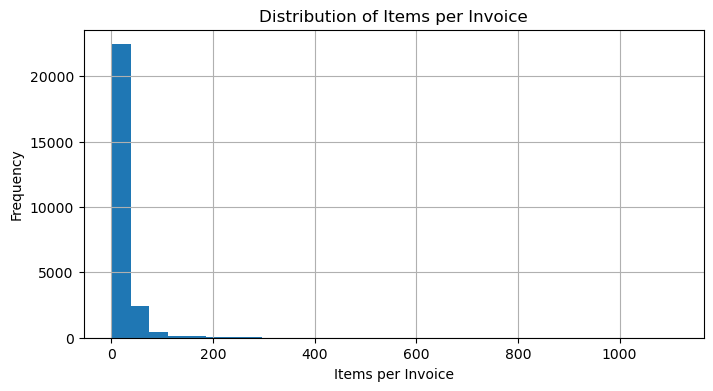

In [26]:
plt.figure(figsize=(8,4))
items_per_invoice.hist(bins=30)
plt.title("Distribution of Items per Invoice")
plt.xlabel("Items per Invoice")
plt.ylabel("Frequency")
plt.show()

#### *StockCode*

**Observations (Summary):**
- Datatype: `object`, Total Rows: 541,909, Unique: 25,900  
- No missing values detected  
- StockCode length mostly 5–6 characters (max = 12)  
- Presence of **non-numeric codes** (e.g., `DOT`, `POST`, `BANK CHARGES`) → 54,873 rows  
- Some StockCodes map to **multiple product descriptions**  
- Frequent StockCodes: `85123A`, `22423`, `85099B`, `47566`  
- Top revenue generators: `DOT`, `22423`, `47566`, `85123A`, `85099B`  

---

**Steps for Data Cleaning**
1. Convert all StockCodes to string & uppercase  
2. Handle/remove special codes (e.g., `DOT`, `POST`, `BANK CHARGES`)  
3. Standardize inconsistent cases (e.g., `47591b` → `47591B`)  
4. Flag/handle very rare StockCodes (appearing once)  
5. Resolve cases where a StockCode maps to multiple descriptions  
6. Validate StockCode–Description mapping with Quantity/Revenue  


In [27]:
df["StockCode"].dtype

dtype('O')

In [28]:
df["StockCode"].shape[0]

541909

In [29]:
df["StockCode"].unique()

array(['85123A', 71053, '84406B', ..., '90214U', '47591b', 23843],
      dtype=object)

In [33]:
df["StockCode"].isna().sum()

0

In [34]:
df['StockCode'].unique()[:20]

array(['85123A', 71053, '84406B', '84029G', '84029E', 22752, 21730, 22633,
       22632, 84879, 22745, 22748, 22749, 22310, 84969, 22623, 22622,
       21754, 21755, 21777], dtype=object)

In [35]:
# Frequency distribution
stock_counts = df['StockCode'].value_counts()
print(stock_counts.head(10))  # top 10 most sold products
print(stock_counts.tail(10))  # least frequent products

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
Name: count, dtype: int64
StockCode
90126A    1
84803A    1
90152C    1
84596g    1
85065     1
21431     1
22275     1
17001     1
90187A    1
72759     1
Name: count, dtype: int64


In [36]:
# Check format (should be alphanumeric, mostly 5-6 digits, but may have special codes)
df['StockCode_Length'] = df['StockCode'].astype(str).apply(len)
print(df['StockCode_Length'].describe())

count    541909.000000
mean          5.086845
std           0.360276
min           1.000000
25%           5.000000
50%           5.000000
75%           5.000000
max          12.000000
Name: StockCode_Length, dtype: float64


In [37]:
# Find non-numeric or special StockCodes (e.g., 'POST', 'DOT', 'BANK CHARGES')
non_numeric_stock = df[~df['StockCode'].astype(str).str.isnumeric()]['StockCode'].unique()
print("Non-numeric StockCodes:", non_numeric_stock)

Non-numeric StockCodes: ['85123A' '84406B' '84029G' ... '85179a' '90214U' '47591b']


In [38]:
# Count how many rows are non-numeric StockCodes
non_numeric_count = df[~df['StockCode'].astype(str).str.isnumeric()].shape[0]
print("Rows with non-numeric StockCodes:", non_numeric_count)

Rows with non-numeric StockCodes: 54873


In [39]:
# Relationship with Description (sometimes StockCode may be reused or inconsistent)
dup_stock_desc = df.groupby('StockCode')['Description'].nunique().sort_values(ascending=False)
print("StockCodes with multiple descriptions:", dup_stock_desc.head(10))

StockCodes with multiple descriptions: StockCode
20713     8
23084     7
21830     6
85175     6
21181     5
23343     5
85172     5
72807A    5
23131     5
22837     4
Name: Description, dtype: int64


In [40]:
# Relationship with Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']
stock_revenue = df.groupby('StockCode')['Revenue'].sum().sort_values(ascending=False)
print("Top 10 revenue generating products:\n", stock_revenue.head(10))

Top 10 revenue generating products:
 StockCode
DOT       206245.48
22423     164762.19
47566      98302.98
85123A     97894.50
85099B     92356.03
23084      66756.59
POST       66230.64
22086      63791.94
84879      58959.73
79321      53768.06
Name: Revenue, dtype: float64


In [41]:
# Basket size per StockCode (how many invoices contained each product)
stock_invoices = df.groupby('StockCode')['InvoiceNo'].nunique().sort_values(ascending=False)
print("Most common products across invoices:\n", stock_invoices.head(10))

Most common products across invoices:
 StockCode
85123A    2246
22423     2172
85099B    2135
47566     1706
20725     1608
84879     1468
22720     1462
22197     1442
21212     1334
22383     1306
Name: InvoiceNo, dtype: int64


### *Description*

**Observations (Summary):**
- Datatype: `object`, Total Rows: 541,909, Unique Values: 1,454  
- No missing values overall, but some `StockCodes` have missing/blank descriptions  
- Text length: mostly **23–31 characters** (max = 35)  
- Top descriptions: `WHITE HANGING HEART T-LIGHT HOLDER`, `REGENCY CAKESTAND 3 TIER`, `JUMBO BAG RED RETROSPOT`  
- Rare/erroneous descriptions include: `"Display"`, `"Missing"`, `"historic computer difference?....se"`  
- Around **55,302 descriptions** contain special characters (e.g., dots, symbols)  
- Several `StockCodes` map to **multiple different descriptions** (e.g., `20713`, `23084`, `85175`)  

---

**Steps for Data Cleaning**
1. **Handle missing descriptions** → Impute using `StockCode` mapping or remove if invalid  
2. **Standardize text** → Convert to uppercase, strip whitespace  
3. **Remove/replace erroneous entries** (e.g., `"Missing"`, `"Display"`, gibberish text)  
4. **Clean special characters** (retain only meaningful alphanumeric text)  
5. **Resolve StockCode–Description conflicts** → keep the most frequent/valid mapping  
6. Optionally perform **text preprocessing** (remove stopwords, lemmatization) for product categorization  

In [43]:
df["Description"].dtype

dtype('O')

In [44]:
df["Description"].shape[0]

541909

In [45]:
df['Description'].isna().sum()

1454

In [48]:
#Sample unique values
print("Sample Descriptions:", df['Description'].unique()[:20])

Sample Descriptions: ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.' 'SET 7 BABUSHKA NESTING BOXES'
 'GLASS STAR FROSTED T-LIGHT HOLDER' 'HAND WARMER UNION JACK'
 'HAND WARMER RED POLKA DOT' 'ASSORTED COLOUR BIRD ORNAMENT'
 "POPPY'S PLAYHOUSE BEDROOM " "POPPY'S PLAYHOUSE KITCHEN"
 'FELTCRAFT PRINCESS CHARLOTTE DOLL' 'IVORY KNITTED MUG COSY '
 'BOX OF 6 ASSORTED COLOUR TEASPOONS' 'BOX OF VINTAGE JIGSAW BLOCKS '
 'BOX OF VINTAGE ALPHABET BLOCKS' 'HOME BUILDING BLOCK WORD'
 'LOVE BUILDING BLOCK WORD' 'RECIPE BOX WITH METAL HEART']


In [49]:
# Frequency analysis
print("Top 10 most common descriptions:")
print(df['Description'].value_counts().head(10))

Top 10 most common descriptions:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64


In [51]:
print("Top 10 least common descriptions:")
print(df['Description'].value_counts().tail(10))

Top 10 least common descriptions:
Description
BAROQUE BUTTERFLY EARRINGS RED         1
ORANGE/FUSCHIA STONES NECKLACE         1
MARIE ANTOIENETT TRINKET BOX GOLD      1
Display                                1
BLACKCHRISTMAS TREE 30CM               1
Missing                                1
historic computer difference?....se    1
DUSTY PINK CHRISTMAS TREE 30CM         1
WRAP BLUE RUSSIAN FOLKART              1
PINK BERTIE MOBILE PHONE CHARM         1
Name: count, dtype: int64


In [52]:
# Description length
df['Description_Length'] = df['Description'].astype(str).apply(len)
print(df['Description_Length'].describe())

count    541909.000000
mean         26.580341
std           5.578571
min           1.000000
25%          23.000000
50%          27.000000
75%          31.000000
max          35.000000
Name: Description_Length, dtype: float64


In [53]:
# Check for duplicates or inconsistencies
# (Same StockCode mapping to different descriptions is critical)
desc_mapping = df.groupby('StockCode')['Description'].nunique()
print("StockCodes with multiple descriptions:")
print(desc_mapping[desc_mapping > 1].sort_values(ascending=False).head(10))

StockCodes with multiple descriptions:
StockCode
20713     8
23084     7
85175     6
21830     6
21181     5
85172     5
23131     5
72807A    5
23343     5
23118     4
Name: Description, dtype: int64


In [54]:
# Check for non-alphabetic or unusual characters in descriptions
df['NonAlpha_Description'] = df['Description'].astype(str).apply(
    lambda x: any(not c.isalnum() and not c.isspace() for c in x)
)
print("Rows with special characters in Description:", df['NonAlpha_Description'].sum())

Rows with special characters in Description: 55302


In [55]:
# Missing value analysis (how many StockCodes lack Description)
missing_desc = df[df['Description'].isna()]
print("StockCodes with missing Description:", missing_desc['StockCode'].unique()[:20])

StockCodes with missing Description: [22139 21134 22145 37509 '85226A' 85044 20950 37461 84670 21777 '84952C'
 35951 22712 22028 85067 21421 21414 21653 21651 85126]


### *Quantity*

**Observations (Summary):**
- Datatype: `int64`, Total Rows: 541,909, Unique Values: 722  
- No missing values detected  
- Distribution shows heavy skew with extreme outliers  
- Typical range:  
  - 25% = 1, Median = 3, 75% = 10  
  - Mean = ~9.55 (much higher std = 218.08)  
- Values range from **-80,995 to +80,995**  
- **Negative quantities** detected → 10,624 rows (likely returns/cancellations)  
- **Zero quantities** → none  
- **Most frequent quantities**: 1, 2, 12, 6, 4, 3, 24, 10  
- **Extreme outliers**: 4,950 rows > 99th percentile (Quantity > 100)  

---

**Steps for Data Cleaning**
1. Validate negative quantities — decide whether to keep (for returns) or separate them.  
2. Check for erroneous extreme values (e.g., `Quantity = 80,995`) and cap/remove if invalid.  
3. Ensure `Quantity` > 0 for normal sales records.  
4. Investigate unusual bulk quantities (top outliers) for possible data entry errors.  
5. Standardize handling of returns (negative values) in further analysis.  


In [56]:
print("Datatype:", df['Quantity'].dtype)

Datatype: int64


In [57]:
print("Total Rows:", df['Quantity'].shape[0])

Total Rows: 541909


In [58]:
print("Missing Values:", df['Quantity'].isna().sum())

Missing Values: 0


In [59]:
print("Unique Values:", df['Quantity'].nunique())

Unique Values: 722


In [61]:
# Summary statistics
print("\nDescriptive Statistics:")
print(df['Quantity'].describe())


Descriptive Statistics:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64


In [62]:
# Distribution of values
print("\nTop 10 Most Frequent Quantities:")
print(df['Quantity'].value_counts().head(10))


Top 10 Most Frequent Quantities:
Quantity
1     148227
2      81829
12     61063
6      40868
4      38484
3      37121
24     24021
10     22288
8      13129
5      11757
Name: count, dtype: int64


In [63]:
print("\nTop 10 Least Frequent Quantities:")
print(df['Quantity'].value_counts().tail(10))


Top 10 Least Frequent Quantities:
Quantity
-9058     1
-1515     1
 1515     1
-204      1
-618      1
-472      1
-161      1
-1206     1
-272      1
-80995    1
Name: count, dtype: int64


In [66]:
# Negative & zero quantities (possible returns/cancellations)
neg_qty = df[df['Quantity'] < 0]
zero_qty = df[df['Quantity'] == 0]
print("\nNegative Quantities count:", len(neg_qty))
print("Zero Quantities count:", len(zero_qty))


Negative Quantities count: 10624
Zero Quantities count: 0


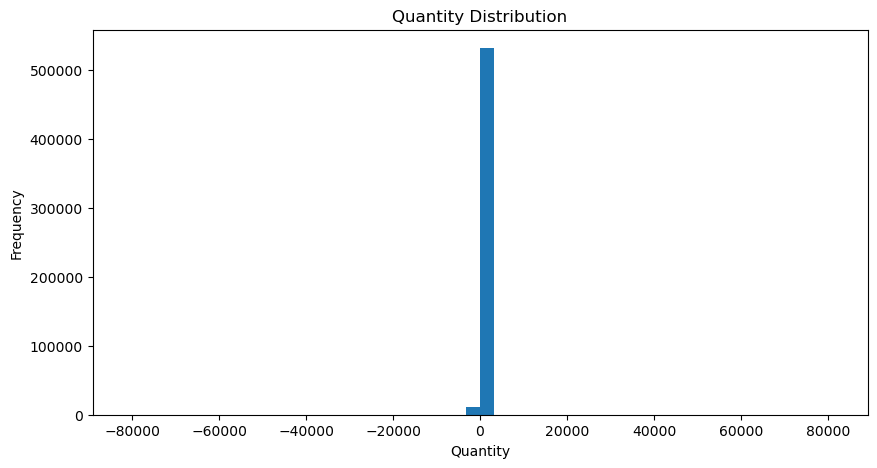

In [67]:
# Boxplot & histogram for distribution
plt.figure(figsize=(10,5))
plt.hist(df['Quantity'], bins=50)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

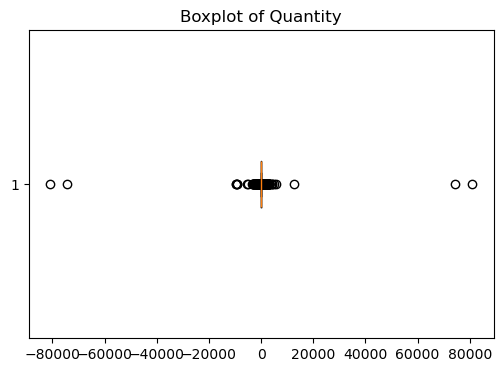

In [68]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Quantity'], vert=False)
plt.title("Boxplot of Quantity")
plt.show()

In [69]:
# Check extreme outliers (very high quantities)
q99 = df['Quantity'].quantile(0.99)
q_max = df['Quantity'].max()
print("\n99th Percentile Quantity:", q99)
print("Maximum Quantity:", q_max)

outliers = df[df['Quantity'] > q99]
print("Rows with extreme quantities:", outliers.shape[0])


99th Percentile Quantity: 100.0
Maximum Quantity: 80995
Rows with extreme quantities: 4950


### *InvoiceDate*

**Observations (Summary):**
- Datatype: `datetime64[ns]`, Total Rows: 541,909, Missing Values: 0  
- Unique Values: 23,260  
- Sample Values:  
  - `2011-06-21 16:35:00`, `2011-11-22 15:41:00`, `2011-11-29 15:06:00`  
- Date Range: **2010-12-01 08:26:00 → 2011-12-09 12:50:00**  
- Invalid/Coerced NaT values: 0  

**Extracted Components:**  
- Year, Month, Day, Hour, Weekday successfully extracted for temporal analysis.  
- Sample:  
  - Year = 2010, Month = 12, Day = 1, Hour = 8, Weekday = Wednesday  

**Transaction Distribution:**  
- **By Year** → 2010: 42,481, 2011: 499,428  
- **By Month** → Peak in Nov (84,711), followed by Dec (68,006), Oct (60,742)  
- **By Weekday** → Thursday (103,857) & Tuesday (101,808) highest, Friday lower (82,193)  
- **By Hour** → Sales peak between **10 AM – 4 PM** (most transactions at 12–3 PM)  

---

**Steps for Data Cleaning / Preparation**  
1. Ensure all timestamps are in proper `datetime64[ns]` format.  
2. Check for **time-zone consistency** (if data comes from multiple regions).  
3. Flag any **future/past outliers** beyond business period.  
4. Standardize to **local business hours** if needed.  
5. Handle **partial day coverage** (e.g., very low transactions at 6–7 AM, 8 PM onwards).  

---

**Next Steps for Data Analysis**  
1. **Seasonality Analysis** → monthly/weekly sales trends.  
2. **Peak Hours Identification** → focus promotions during 10 AM – 4 PM.  
3. **Day-of-Week Impact** → compare weekday vs. weekend sales performance.  
4. **Year-over-Year Growth** → evaluate 2010 → 2011 growth.  
5. **Holiday / Event Impact** → investigate spikes in Nov–Dec (holiday shopping).  
6. Create **time-series plots** (line plots, heatmaps by weekday-hour).  


In [70]:
print("Datatype:", df['InvoiceDate'].dtype)

Datatype: datetime64[ns]


In [71]:
print("Total Rows:", df['InvoiceDate'].shape[0])

Total Rows: 541909


In [72]:
print("Missing Values:", df['InvoiceDate'].isnull().sum())

Missing Values: 0


In [73]:
print("Unique Values:", df['InvoiceDate'].nunique())

Unique Values: 23260


In [74]:
print("\nSample values:")
print(df['InvoiceDate'].sample(10).values)


Sample values:
['2011-06-21T16:35:00.000000000' '2011-11-22T15:41:00.000000000'
 '2011-11-29T15:06:00.000000000' '2011-11-08T13:10:00.000000000'
 '2011-02-22T17:25:00.000000000' '2011-10-20T13:06:00.000000000'
 '2011-07-20T13:26:00.000000000' '2011-05-09T16:30:00.000000000'
 '2011-08-18T12:30:00.000000000' '2011-06-12T09:56:00.000000000']


In [75]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [76]:
print("\nDate Range:")
print("Min:", df['InvoiceDate'].min())
print("Max:", df['InvoiceDate'].max())


Date Range:
Min: 2010-12-01 08:26:00
Max: 2011-12-09 12:50:00


In [77]:
print("\nInvalid/Coerced NaT values:", df['InvoiceDate'].isna().sum())


Invalid/Coerced NaT values: 0


In [78]:
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['InvoiceWeekday'] = df['InvoiceDate'].dt.day_name()

In [79]:
print("\nExtracted Components Sample:")
print(df[['InvoiceDate','InvoiceYear','InvoiceMonth','InvoiceDay','InvoiceHour','InvoiceWeekday']].head())


Extracted Components Sample:
          InvoiceDate  InvoiceYear  InvoiceMonth  InvoiceDay  InvoiceHour  \
0 2010-12-01 08:26:00         2010            12           1            8   
1 2010-12-01 08:26:00         2010            12           1            8   
2 2010-12-01 08:26:00         2010            12           1            8   
3 2010-12-01 08:26:00         2010            12           1            8   
4 2010-12-01 08:26:00         2010            12           1            8   

  InvoiceWeekday  
0      Wednesday  
1      Wednesday  
2      Wednesday  
3      Wednesday  
4      Wednesday  


In [81]:
print("\nTransactions per Year:")
print(df['InvoiceYear'].value_counts().sort_index())


Transactions per Year:
InvoiceYear
2010     42481
2011    499428
Name: count, dtype: int64


In [82]:
print("\nTransactions per Month:")
print(df['InvoiceMonth'].value_counts().sort_index())


Transactions per Month:
InvoiceMonth
1     35147
2     27707
3     36748
4     29916
5     37030
6     36874
7     39518
8     35284
9     50226
10    60742
11    84711
12    68006
Name: count, dtype: int64


In [83]:
print("\nTransactions by Weekday:")
print(df['InvoiceWeekday'].value_counts())


Transactions by Weekday:
InvoiceWeekday
Thursday     103857
Tuesday      101808
Monday        95111
Wednesday     94565
Friday        82193
Sunday        64375
Name: count, dtype: int64


In [84]:
print("\nTransactions by Hour:")
print(df['InvoiceHour'].value_counts().sort_index())


Transactions by Hour:
InvoiceHour
6        41
7       383
8      8909
9     34332
10    49037
11    57674
12    78709
13    72259
14    67471
15    77519
16    54516
17    28509
18     7974
19     3705
20      871
Name: count, dtype: int64


In [ ]:
`UnitPrice`

In [86]:
print("Datatype:", df['UnitPrice'].dtype)

Datatype: float64


In [87]:
print("Total Rows:", len(df))

Total Rows: 541909


In [85]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'InvoiceNo_Length', 'Revenue',
       'StockCode_Length', 'Description_Length', 'NonAlpha_Description',
       'InvoiceYear', 'InvoiceMonth', 'InvoiceDay', 'InvoiceHour',
       'InvoiceWeekday'],
      dtype='object')